**Analise Telco Customer churn**



Fonte de dados: base real dataset IMB

- Analise Exploratoria para entendimento do Churn e seus respectivos motivos bem como teste preditivos
- Quais fatores influenciam diretamente no churn?
- otimização de campanha de marketing?

 ⚠️ **Observações:**
 - `TotalCharges` está como `object` no dataset original — contém strings vazias `" "` que quebram a conversão direta pra `float`.
 - `SeniorCitizen` já vem como 0/1, enquanto os demais binários vêm como "Yes"/"No" — inconsistência a padronizar.
 - Colunas com "No internet service" ou "No phone service" são redundantes com `InternetService`/`PhoneService` e podem ser simplificadas para Yes/No.

In [14]:
#Importar as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# abrir o arquivo CSV
df = pd.read_csv("Telco-Customer-Churn.csv")
df.info()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

1. Limpeza de dados e processamento

- Possui dados vazios?
- Possui necessidade de correção de tipo de dado

In [6]:

# Checar valores nulos no DataFrame


df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:

# Converter a coluna 'TotalCharges' para o tipo numérico, tratando erros de conversão
# Função pd.to_numeric() do pandas é usada para converter uma coluna ou Series para um tipo numérico.


df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce' # Trata erros de conversão como valores nulos
)

print(
    df['TotalCharges'].dtype
)

float64


In [9]:
# checar novamente valores nulos no DataFrame após a conversão

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# Preencher valores nulos na coluna 'TotalCharges' com a mediana da coluna 
# Função fillna() do pandas é usada para preencher valores nulos em um DataFrame ou Series. 
# No caso do código fornecido, a função fillna() está sendo aplicada à coluna 'TotalCharges' do DataFrame df.

df['TotalCharges'] = (
    df['TotalCharges']
    .fillna(
        df['TotalCharges']
        .median()
    )
)

df.isnull().sum().sum()

np.int64(0)

In [6]:
# Mostrar as primeiras 5 linhas do DataFrame para entendimento dos dados
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📖 Dicionário de Dados — Telco Customer Churn

| Coluna | Tipo | Descrição |
|---|---|---|
| `customerID` | string | ID único do cliente (apenas identificador, não usar como feature) |
| `gender` | categórica | Gênero do cliente (Male / Female) |
| `SeniorCitizen` | binária (0/1) | Se o cliente é idoso (1) ou não (0) |
| `Partner` | categórica | Se o cliente tem parceiro/cônjuge (Yes/No) |
| `Dependents` | categórica | Se o cliente tem dependentes (Yes/No) |
| `tenure` | numérica | Meses que o cliente está na empresa (0 a 72) |
| `PhoneService` | categórica | Se possui serviço de telefone (Yes/No) |
| `MultipleLines` | categórica | Se possui múltiplas linhas (Yes / No / No phone service) |
| `InternetService` | categórica | Tipo de internet (DSL / Fiber optic / No) |
| `OnlineSecurity` | categórica | Serviço de segurança online (Yes / No / No internet service) |
| `OnlineBackup` | categórica | Backup online (Yes / No / No internet service) |
| `DeviceProtection` | categórica | Proteção de dispositivo (Yes / No / No internet service) |
| `TechSupport` | categórica | Suporte técnico (Yes / No / No internet service) |
| `StreamingTV` | categórica | Streaming de TV (Yes / No / No internet service) |
| `StreamingMovies` | categórica | Streaming de filmes (Yes / No / No internet service) |
| `Contract` | categórica | Tipo de contrato (Month-to-month / One year / Two year) |
| `PaperlessBilling` | categórica | Se usa fatura sem papel (Yes/No) |
| `PaymentMethod` | categórica | Forma de pagamento (Electronic check / Mailed check / Bank transfer / Credit card) |
| `MonthlyCharges` | numérica | Valor cobrado mensalmente |
| `TotalCharges` | numérica* | Valor total cobrado (*vem como string, precisa converter e tratar espaços em branco) |
| `Churn` | **target** | Se o cliente cancelou o serviço (Yes/No) |



1. Calculo real de churn e seus **percentuais** respectivos bem como representação visual

In [7]:
# Distribuição do churn e % do total

contagem = df["Churn"].value_counts()
percentual = df["Churn"].value_counts(normalize=True) * 100 #formula para calcular o percentual

# cria um DataFrame com a contagem e o percentual
Resumo_churn = pd.DataFrame({
    "Contagem": contagem,
      "Percentual (%)": percentual.round(2) #cria a coluna percentual com 2 casas decimais
      })

Resumo_churn

,Contagem,Percentual (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


__Dos 7.043 Clientes analisados aproximadamente 27% (1.869) estão mapeados como Churn__

2. Representação visual inicial: Grafico de colunas

Figura 1: Representação grafica de Distribuição de Churn


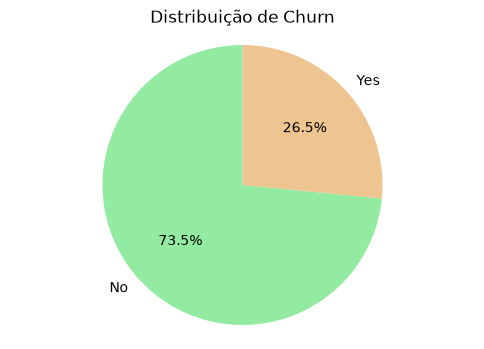

Futuramente pensar em melhorar o grafico com outras cores e legendas, talvez com um grafico de barras


In [8]:
# Churn mostrado em grafico de pizza

plt.figure(figsize=(6, 4))
plt.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90, colors=["#92eba1","#eec590"])
plt.title('Distribuição de Churn')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
print("Figura 1: Representação grafica de Distribuição de Churn")
plt.show()
print("Futuramente pensar em melhorar o grafico com outras cores e legendas, talvez com um grafico de barras")

Figura 2: Representação grafica de Distribuição de Churn por Gênero


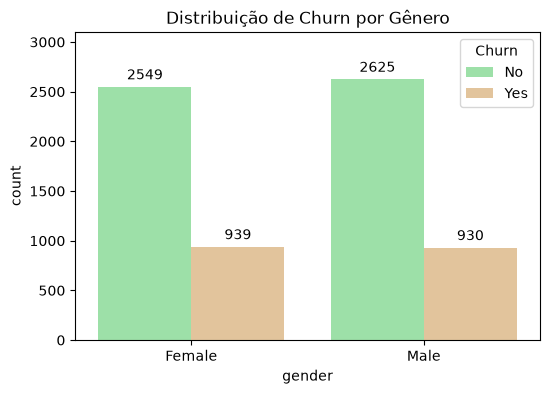

In [28]:
# Criar um gráfico de barras para visualizar a distribuição de churn por gênero

plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='Churn', data=df, # Escolha do eixo x, a variável de interesse e o DataFrame
              palette={"No": "#92eba1", "Yes": "#eec590"}) # Escolha de cores para cada categoria de churn
plt.title('Distribuição de Churn por Gênero')
plt.legend(title='Churn', loc='upper right')
print("Figura 2: Representação grafica de Distribuição de Churn por Gênero")

for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3) # adiciona os valores acima das barras para melhor visualização
plt.ylim(0, 3100) # Maximo eixo y para melhor visualização dos valores
plt.show()

Aparentemente , não há uma diferença significativa na taxa de churn entre os gêneros masculino e feminino. A distribuição de churn parece ser relativamente equilibrada entre os dois grupos, sugerindo que o gênero pode não ser um fator determinante para a probabilidade de churn neste conjunto de dados.